<a href="https://colab.research.google.com/github/ap-ctrl/celebal_ankita/blob/main/week4_ankita_priyadarshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4084s 24us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Dataset Information

In [ ]:
print("=" * 50)
print("CIFAR-10 Dataset Information")
print("=" * 50)

print(f"Training Images : {x_train.shape[0]}")
print(f"Testing Images : {x_test.shape[0]}")

print(f"Training Shape : {x_train.shape}")
print(f"Testing Shape : {x_test.shape}")

print(f"Image Size : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Channels : {x_train.shape[3]}")

CIFAR-10 Dataset Information
Training Images : 50000
Testing Images : 10000
Training Shape : (50000, 32, 32, 3)
Testing Shape : (10000, 32, 32, 3)
Image Size : 32 x 32
Channels : 3


Class Names

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

for i, name in enumerate(class_names):
    print(f"{i} : {name}")

0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck


Pixel Value Range

In [ ]:
print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

Minimum Pixel Value : 0
Maximum Pixel Value : 255


Number of Images Per Class

In [ ]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]} : {count}")

Airplane : 5000
Automobile : 5000
Bird : 5000
Cat : 5000
Deer : 5000
Dog : 5000
Frog : 5000
Horse : 5000
Ship : 5000
Truck : 5000


Display One Image From Each Class

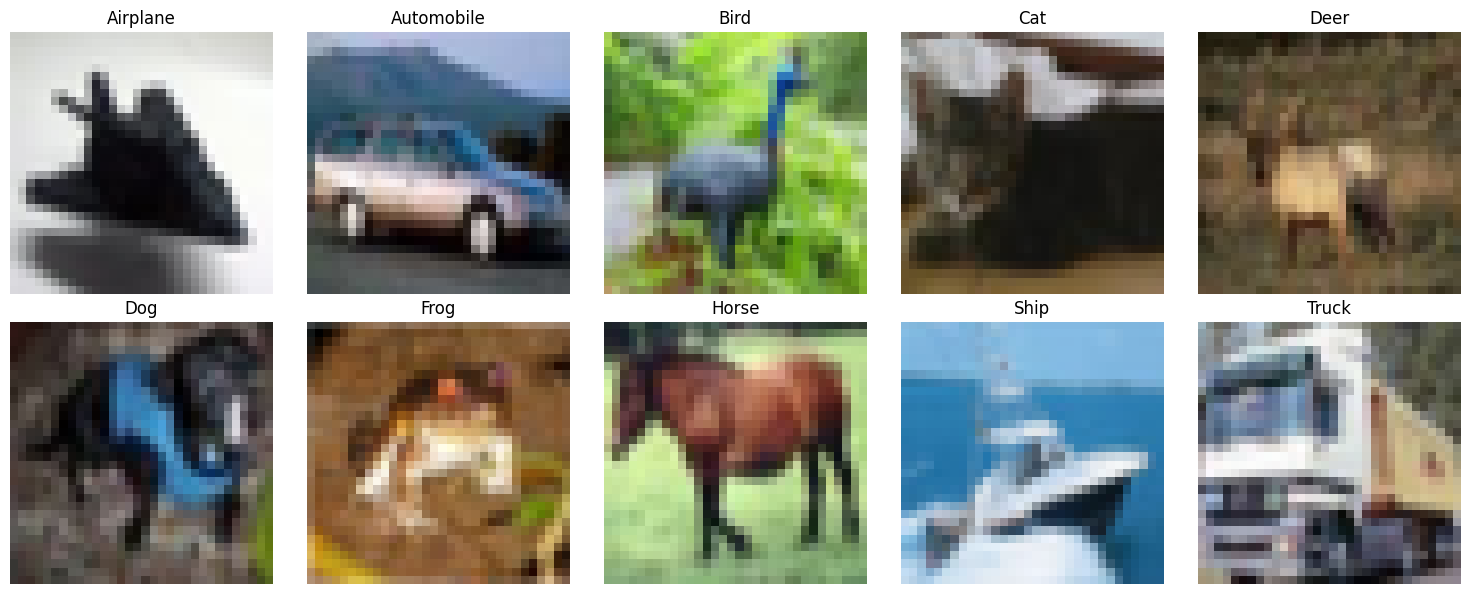

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

for i in range(10):

    idx = np.where(y_train == i)[0][0]

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx])
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 🖼️ Visualize Sample Images

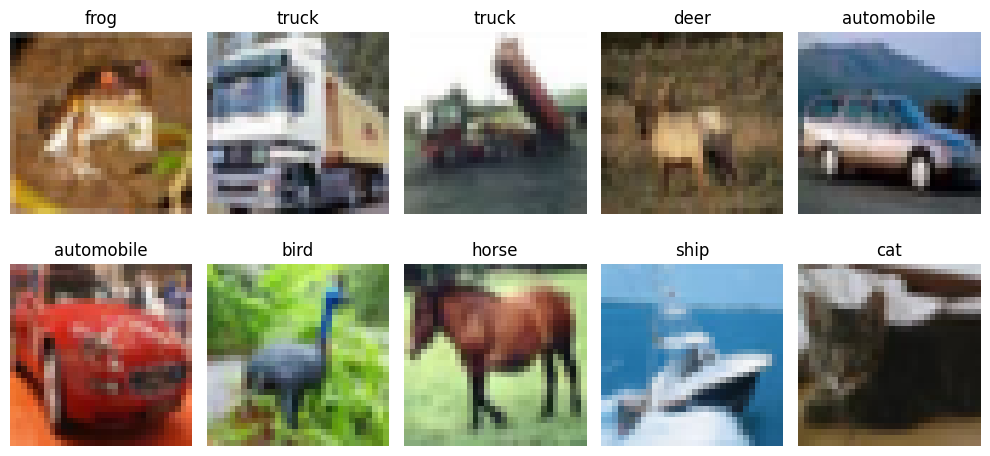

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [ ]:
print("Original Shape :", x_train.shape)

print("Normalized Shape :", x_train_norm.shape)

print("Flattened Shape :", x_train_flat.shape)

Original Shape : (50000, 32, 32, 3)
Normalized Shape : (50000, 32, 32, 3)
Flattened Shape : (50000, 3072)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.2688 - loss: 1.9977 - val_accuracy: 0.3126 - val_loss: 1.8600
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3251 - loss: 1.8588 - val_accuracy: 0.3732 - val_loss: 1.7585
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3420 - loss: 1.8030 - val_accuracy: 0.3878 - val_loss: 1.7356
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3597 - loss: 1.7661 - val_accuracy: 0.3666 - val_loss: 1.7457
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3671 - loss: 1.7399 - val_accuracy: 0.4074 - val_loss: 1.6762
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3784 - loss: 1.7137 - val_accuracy: 0.4054 - val_loss: 1.6669
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3821 - loss: 1.7062 - val_accuracy: 0.4162 - val_loss: 1.6656
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3847 - loss: 1.6887 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4312 - loss: 1.6177
ANN Test Accuracy: 0.4311999976634979


In [ ]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121,824 (19.54 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,414,550 (13.03 MB)

In [ ]:
print("\nTotal Parameters :", ann_model.count_params())


Total Parameters : 1707274


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4542 - loss: 1.5174 - val_accuracy: 0.4708 - val_loss: 1.5100
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 124ms/step - accuracy: 0.5939 - loss: 1.1576 - val_accuracy: 0.5878 - val_loss: 1.1893
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6600 - loss: 0.9760 - val_accuracy: 0.6762 - val_loss: 0.9230
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 122ms/step - accuracy: 0.7050 - loss: 0.8471 - val_accuracy: 0.6388 - val_loss: 1.1334
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.7349 - loss: 0.7524 - val_accuracy: 0.6964 - val_loss: 0.8740
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.7673 - loss: 0.6706 - val_accuracy: 0.6882 - val_loss: 0.9244
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.7867 - loss: 0.6048 - val_accuracy: 0.7198 - val_loss: 0.8554
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8097 - los

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6915 - loss: 1.1182
CNN Test Accuracy: 0.6915000081062317


In [ ]:
cnn_model.summary()

print()

print("Total Parameters :", cnn_model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,200 (4.09 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 714,006 (2.72 MB)


Total Parameters : 357194


## 📈 Compare Learning Curves

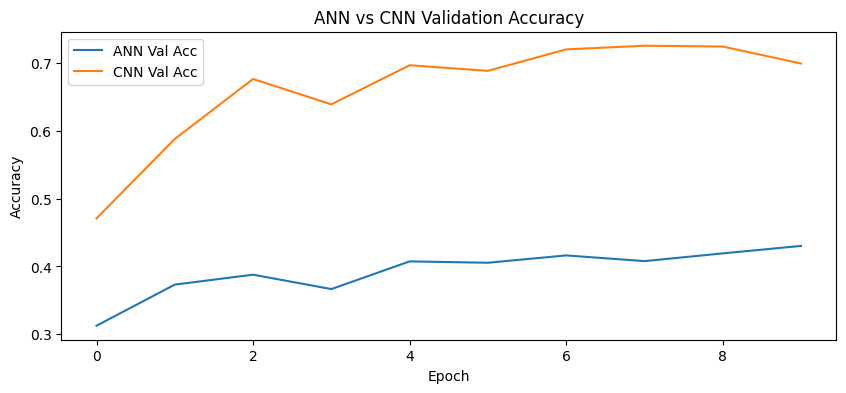

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

Compare Training Loss

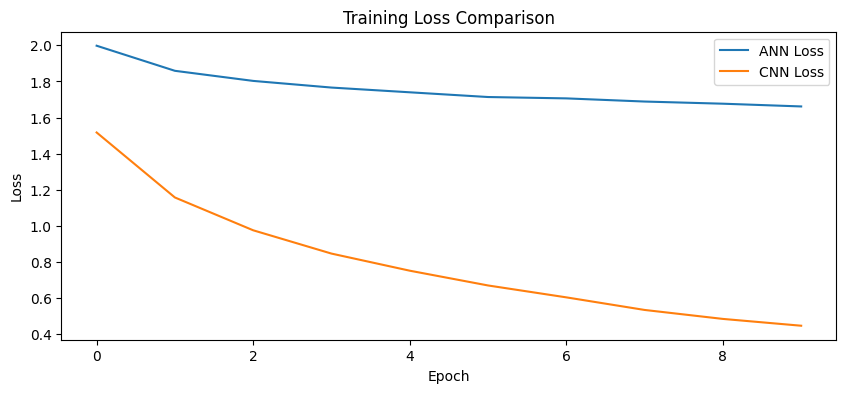

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(ann_history.history["loss"],label="ANN Loss")

plt.plot(cnn_history.history["loss"],label="CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Training Loss Comparison")

plt.show()

# 📉 Compare Validation Loss

Validation loss shows how well the model generalizes to unseen validation data.

Lower validation loss generally indicates better learning and less overfitting.

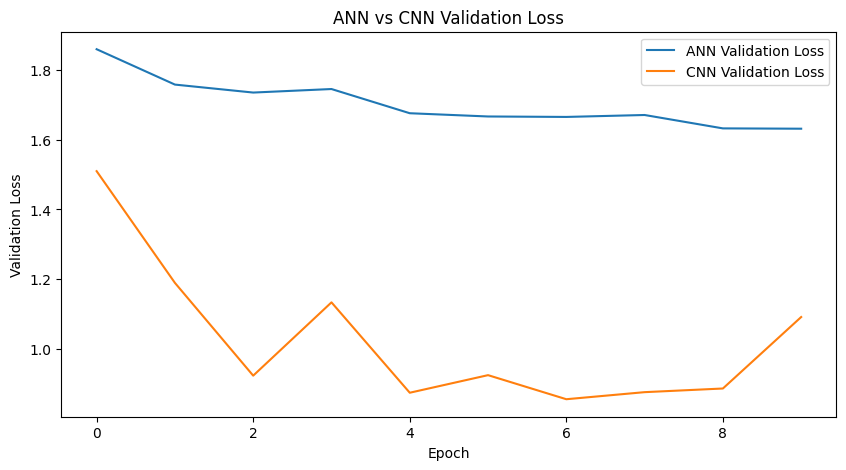

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history["val_loss"], label="ANN Validation Loss")

plt.plot(cnn_history.history["val_loss"], label="CNN Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("ANN vs CNN Validation Loss")

plt.legend()

plt.show()

# 📈 Compare Training Accuracy

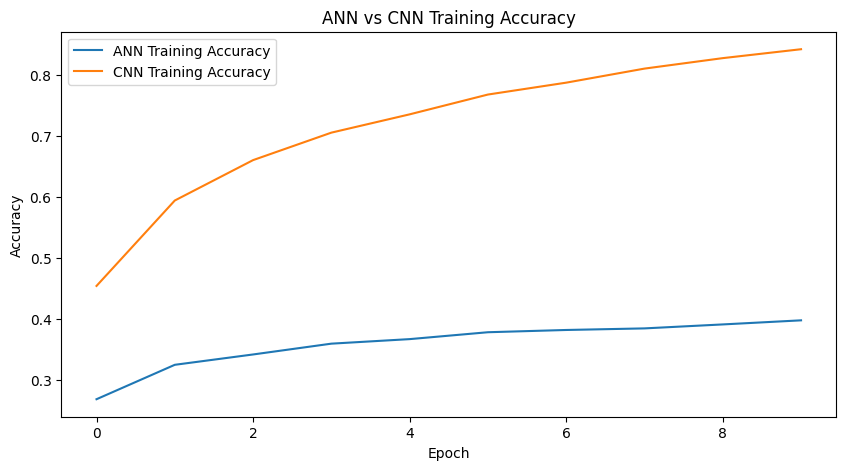

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history["accuracy"], label="ANN Training Accuracy")

plt.plot(cnn_history.history["accuracy"], label="CNN Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("ANN vs CNN Training Accuracy")

plt.legend()

plt.show()

# **Architecture** **Comparison**

In [ ]:
comparison_architecture = pd.DataFrame({

    "Feature":[

        "Input Type",

        "Image Structure",

        "Feature Extraction",

        "Pooling",

        "Flattening",

        "Suitable for Images"

    ],

    "ANN":[

        "3072 Vector",

        "Lost",

        "No",

        "No",

        "Yes",

        "Moderate"

    ],

    "CNN":[

        "32×32×3 Image",

        "Preserved",

        "Yes",

        "Yes",

        "Only Before Dense",

        "Excellent"

    ]

})

comparison_architecture

,Feature,ANN,CNN
0,Input Type,3072 Vector,32×32×3 Image
1,Image Structure,Lost,Preserved
2,Feature Extraction,No,Yes
3,Pooling,No,Yes
4,Flattening,Yes,Only Before Dense
5,Suitable for Images,Moderate,Excellent


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 🚀 Training Strategy 2 : Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

print("EarlyStopping callback created successfully.")

EarlyStopping callback created successfully.


# 🚀 Training Strategy 3: Optimizer Comparison

Different optimizers update the model weights in different ways.
Here we compare the two most common optimizers:

- Adam
- SGD

This helps us understand how the optimizer affects learning speed and final accuracy.

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD

# Build CNN with Adam Optimizer
adam_model = models.clone_model(cnn_model)
adam_model.build((None, 32, 32, 3))

adam_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

adam_history = adam_model.fit(
    x_train_norm,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# Build CNN with SGD Optimizer
sgd_model = models.clone_model(cnn_model)
sgd_model.build((None, 32, 32, 3))

sgd_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sgd_history = sgd_model.fit(
    x_train_norm,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 126ms/step - accuracy: 0.4761 - loss: 1.4750 - val_accuracy: 0.4962 - val_loss: 1.4493
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6169 - loss: 1.1005 - val_accuracy: 0.6070 - val_loss: 1.1563
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.6756 - loss: 0.9303 - val_accuracy: 0.6812 - val_loss: 0.9109
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7157 - loss: 0.8168 - val_accuracy: 0.7120 - val_loss: 0.8575
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.7477 - loss: 0.7195 - val_accuracy: 0.7040 - val_loss: 0.8771
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 121ms/step - accuracy: 0.3739 - loss: 1.7194 - val_accuracy: 0.3448 - val_loss: 2.0093
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.4963 - loss: 1.4080 - val_accuracy: 0.3418 - val_loss: 2.0001
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.5535 - loss: 1.2551 -

# 📊 Confusion Matrix

The confusion matrix shows how many images were correctly classified and which classes were confused with one another.

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


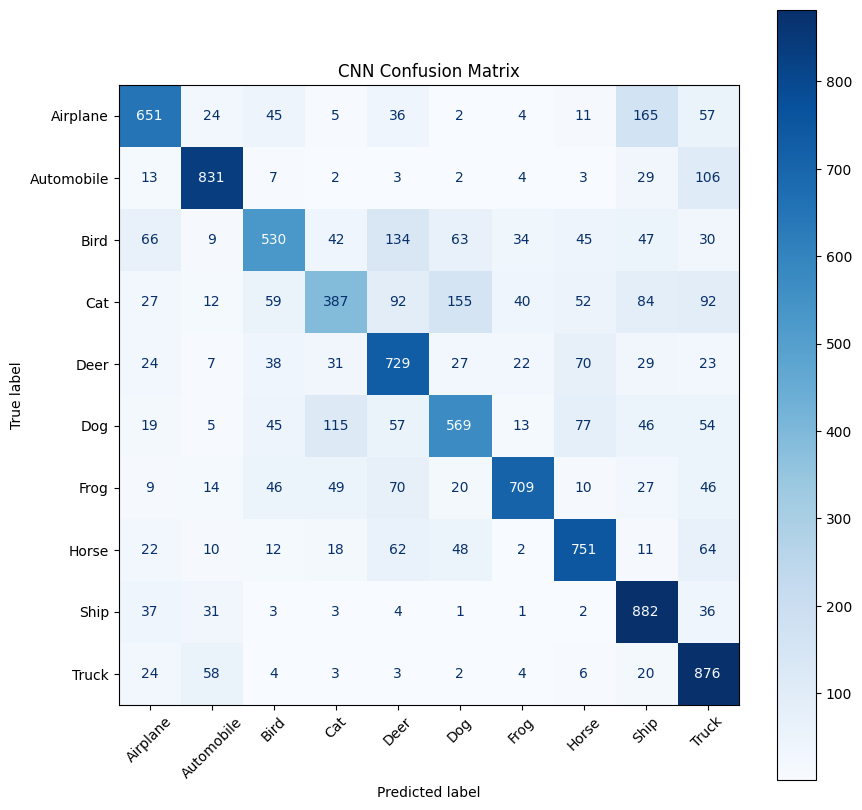

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn_predictions = cnn_model.predict(x_test_norm)

cnn_pred_labels = np.argmax(cnn_predictions, axis=1)

cm = confusion_matrix(y_test, cnn_pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("CNN Confusion Matrix")

plt.show()

# 📑 Classification Report

The classification report provides Precision, Recall, and F1-Score for every class.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,

    cnn_pred_labels,

    target_names=class_names

))

              precision    recall  f1-score   support

    Airplane       0.73      0.65      0.69      1000
  Automobile       0.83      0.83      0.83      1000
        Bird       0.67      0.53      0.59      1000
         Cat       0.59      0.39      0.47      1000
        Deer       0.61      0.73      0.67      1000
         Dog       0.64      0.57      0.60      1000
        Frog       0.85      0.71      0.77      1000
       Horse       0.73      0.75      0.74      1000
        Ship       0.66      0.88      0.75      1000
       Truck       0.63      0.88      0.73      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



# 🖼️ Predict on Individual Test Images

Now that our CNN model has been trained, let's use it to predict the class of unseen test images.

This demonstrates how the trained model performs on real test samples.

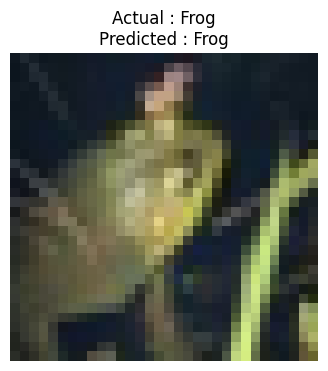

In [ ]:
import random

# Choose a random image from the test dataset
index = random.randint(0, len(x_test_norm)-1)

# Get the image
image = x_test_norm[index]

# Display image
plt.figure(figsize=(4,4))
plt.imshow(x_test[index])
plt.axis("off")

# Actual class
actual_class = class_names[y_test[index][0]]

# Predict class
prediction = cnn_model.predict(image.reshape(1,32,32,3), verbose=0)

predicted_class = class_names[np.argmax(prediction)]

plt.title(f"Actual : {actual_class}\nPredicted : {predicted_class}")

plt.show()

In [ ]:
print("="*50)
print("Prediction Result")
print("="*50)

print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)

confidence = np.max(prediction) * 100

print(f"Confidence Score : {confidence:.2f}%")

Prediction Result
Actual Class    : Frog
Predicted Class : Frog
Confidence Score : 99.99%


# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4312
1,CNN,0.6915


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**